In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Pandas/fashion_boutique.csv")

df.head()

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date
0,FB000001,Outerwear,Zara,Spring,XL,Red,196.01,0.0,196.01,05-07-2025
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,06-08-2025
2,FB000003,Accessories,Uniqlo,Winter,NaN,Black,33.80,0.0,33.80,06-08-2025
3,FB000004,Shoes,Uniqlo,Spring,XL,Black,75.36,0.0,75.36,07-07-2025
4,FB000005,Tops,Banana Republic,Winter,XL,Black,105.02,0.0,105.02,06-08-2025


In [ ]:
df.shape

(2176, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2176 entries, 0 to 2175
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           2176 non-null   object 
 1   category             2176 non-null   object 
 2   brand                2176 non-null   object 
 3   season               2176 non-null   object 
 4   size                 1685 non-null   object 
 5   color                2176 non-null   object 
 6   original_price       2176 non-null   float64
 7   markdown_percentage  2176 non-null   float64
 8   current_price        2176 non-null   float64
 9   purchase_date        2176 non-null   object 
dtypes: float64(3), object(7)
memory usage: 170.1+ KB


In [ ]:
df.isnull().sum()

,0
product_id,0
category,0
brand,0
season,0
size,491
color,0
original_price,0
markdown_percentage,0
current_price,0
purchase_date,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
product_id,object
category,object
brand,object
season,object
size,object
color,object
original_price,float64
markdown_percentage,float64
current_price,float64
purchase_date,object


In [ ]:
df['product_id'] = df['product_id'].astype('string')
df['category'] = df['category'].astype('string')
df['brand'] = df['brand'].astype('string')
df['season'] = df['season'].astype('string')
df['size'] = df['size'].astype('string')
df['color'] = df['color'].astype('string')

df['original_price'] = df['original_price'].astype(float)
df['markdown_percentage'] = df['markdown_percentage'].astype(float)
df['current_price'] = df['current_price'].astype(float)

df['purchase_date'] = pd.to_datetime(
    df['purchase_date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
df.dtypes

,0
product_id,string[python]
category,string[python]
brand,string[python]
season,string[python]
size,string[python]
color,string[python]
original_price,float64
markdown_percentage,float64
current_price,float64
purchase_date,datetime64[ns]


In [ ]:
for col in ['category', 'brand', 'season', 'size', 'color']:
    df[col] = df[col].str.title()

In [ ]:
df.head()

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date
0,FB000001,Outerwear,Zara,Spring,Xl,Red,196.01,0.0,196.01,2025-07-05
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06
2,FB000003,Accessories,Uniqlo,Winter,<NA>,Black,33.80,0.0,33.80,2025-08-06
3,FB000004,Shoes,Uniqlo,Spring,Xl,Black,75.36,0.0,75.36,2025-07-07
4,FB000005,Tops,Banana Republic,Winter,Xl,Black,105.02,0.0,105.02,2025-08-06


In [ ]:
df['size'] = df['size'].fillna('Not_Specified')

In [ ]:
df.isnull().sum()

,0
product_id,0
category,0
brand,0
season,0
size,0
color,0
original_price,0
markdown_percentage,0
current_price,0
purchase_date,0


In [ ]:
df['Month'] = df['purchase_date'].dt.month_name()
df

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,Month
0,FB000001,Outerwear,Zara,Spring,Xl,Red,196.01,0.0,196.01,2025-07-05,July
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,August
2,FB000003,Accessories,Uniqlo,Winter,Not_Specified,Black,33.80,0.0,33.80,2025-08-06,August
3,FB000004,Shoes,Uniqlo,Spring,Xl,Black,75.36,0.0,75.36,2025-07-07,July
4,FB000005,Tops,Banana Republic,Winter,Xl,Black,105.02,0.0,105.02,2025-08-06,August
...,...,...,...,...,...,...,...,...,...,...,...
2171,FB002172,Tops,Mango,Summer,Xl,Black,31.41,0.0,31.41,2025-08-06,August
2172,FB002173,Dresses,Banana Republic,Winter,L,Brown,50.58,0.0,50.58,2025-08-06,August
2173,FB002174,Accessories,Banana Republic,Winter,Not_Specified,Beige,79.37,54.8,35.88,2025-08-06,August
2174,FB002175,Bottoms,Ann Taylor,Summer,Xl,Pink,105.52,0.0,105.52,2025-08-06,August


In [ ]:
df['discount_amount'] = (
    df['original_price'] - df['current_price']
)

In [ ]:
df.head(10)

,product_id,category,brand,season,size,color,original_price,markdown_percentage,current_price,purchase_date,Month,discount_amount
0,FB000001,Outerwear,Zara,Spring,Xl,Red,196.01,0.0,196.01,2025-07-05,July,0.00
1,FB000002,Tops,Uniqlo,Winter,L,Pink,119.64,0.0,119.64,2025-08-06,August,0.00
2,FB000003,Accessories,Uniqlo,Winter,Not_Specified,Black,33.80,0.0,33.80,2025-08-06,August,0.00
3,FB000004,Shoes,Uniqlo,Spring,Xl,Black,75.36,0.0,75.36,2025-07-07,July,0.00
4,FB000005,Tops,Banana Republic,Winter,Xl,Black,105.02,0.0,105.02,2025-08-06,August,0.00
5,FB000006,Accessories,Zara,Fall,Not_Specified,White,35.03,35.4,22.63,2025-08-06,August,12.40
6,FB000007,Bottoms,Zara,Spring,S,Gray,53.83,54.5,24.49,2024-10-29,October,29.34
7,FB000008,Dresses,Mango,Winter,Xl,Blue,91.55,22.1,71.32,2025-08-06,August,20.23
8,FB000009,Outerwear,Uniqlo,Spring,Xl,Green,227.73,12.8,198.58,2025-03-24,March,29.15
9,FB000010,Outerwear,H&M,Fall,Xxl,Pink,248.41,10.9,221.33,2025-08-06,August,27.08


In [ ]:
total_discount = np.sum(df['discount_amount'])

print("Total Discount Amount:", total_discount)

Total Discount Amount: 25460.82


In [ ]:
average_discount = np.mean(df['discount_amount'])

print("Average Discount Amount:", average_discount)

Average Discount Amount: 11.700744485294118


In [ ]:
maximum_discount = np.max(df['discount_amount'])

print("Maximum Discount:", maximum_discount)

Maximum Discount: 132.06


In [ ]:
minimum_discount = np.min(df['discount_amount'])

print("Minimum Discount:", minimum_discount)

Minimum Discount: 0.0


In [ ]:
discount_std = np.std(df['discount_amount'])

print("Standard Deviation:", discount_std)

Standard Deviation: 21.014292072794824


In [ ]:
average_discount = np.mean(df['discount_amount'])

high_discount = df[
    df['discount_amount'] > average_discount
]

print(high_discount)

     product_id     category            brand  season           size   color  \
5      FB000006  Accessories             Zara    Fall  Not_Specified   White   
6      FB000007      Bottoms             Zara  Spring              S    Gray   
7      FB000008      Dresses            Mango  Winter             Xl    Blue   
8      FB000009    Outerwear           Uniqlo  Spring             Xl   Green   
9      FB000010    Outerwear              H&M    Fall            Xxl    Pink   
...         ...          ...              ...     ...            ...     ...   
2153   FB002154         Tops              Gap    Fall             Xl   Black   
2154   FB002155        Shoes           Uniqlo  Summer              S   Black   
2157   FB002158  Accessories       Ann Taylor  Spring  Not_Specified  Purple   
2166   FB002167        Shoes  Banana Republic  Winter              M   Brown   
2173   FB002174  Accessories  Banana Republic  Winter  Not_Specified   Beige   

      original_price  markdown_percenta

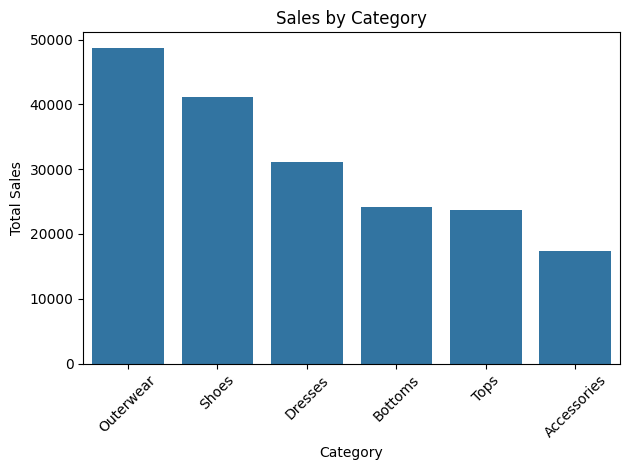

In [ ]:
category_sales = df.groupby('category')['current_price'].sum().sort_values(ascending=False)

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

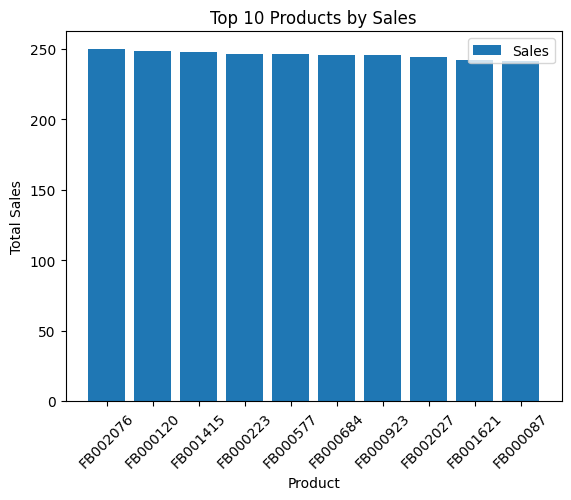

In [ ]:
product_sales = (
    df.groupby('product_id')['current_price']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)



plt.bar(
    product_sales.index,
    product_sales.values,
    label="Sales"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.legend()

plt.show()

In [ ]:
monthly_sales = df.groupby('Month')['current_price'].sum()

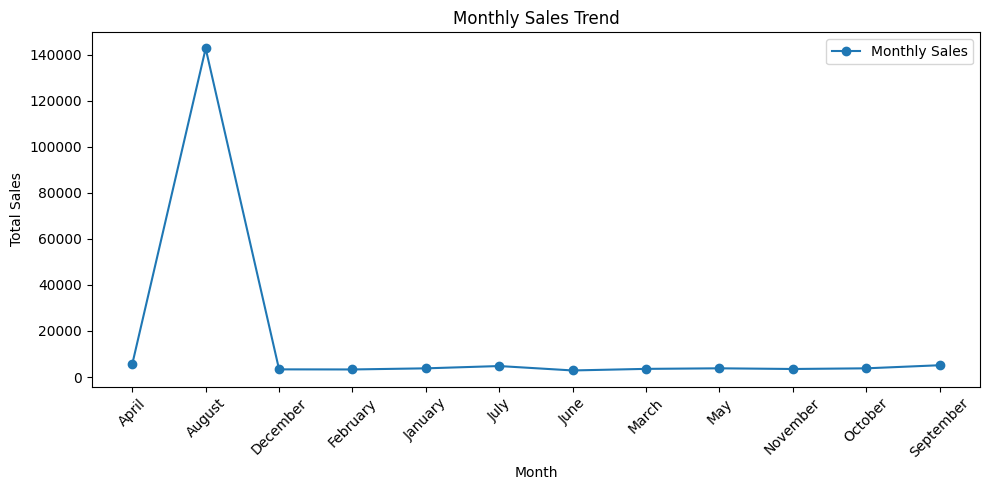

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    label='Monthly Sales'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

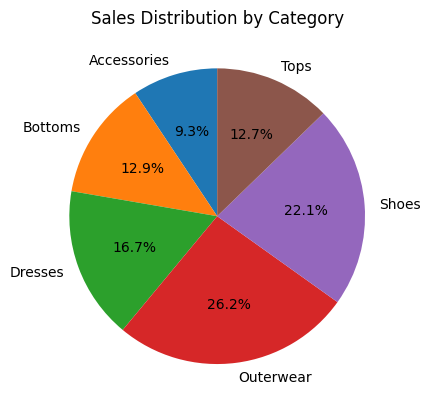

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby('category')['current_price'].sum()


plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales Distribution by Category")

plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/Pandas/fashion_cleaned.csv', index=False)